/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


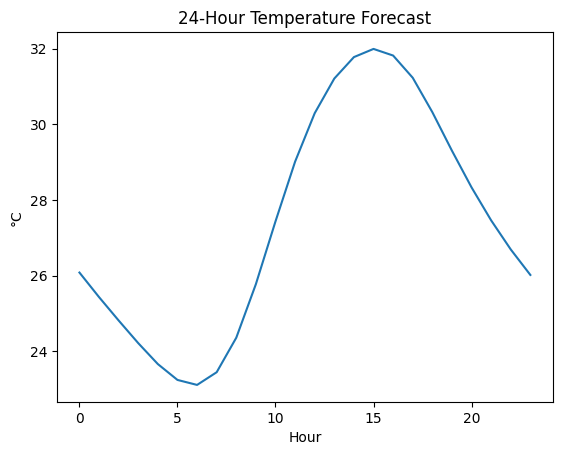

In [1]:
import numpy as np, requests, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Fetch data (Bangalore)
end = (datetime.today() - timedelta(days=1)).strftime('%Y-%m-%d')
r = requests.get('https://archive-api.open-meteo.com/v1/archive',
    params={'latitude':12.97,'longitude':77.59,
            'start_date':'2020-01-01','end_date':end,
            'hourly':'temperature_2m','timezone':'Asia/Kolkata'}).json()

temps = np.array(r['hourly']['temperature_2m'], dtype=float)
temps = temps[~np.isnan(temps)]

# Scale + create sequences
scaler = MinMaxScaler()
s = scaler.fit_transform(temps.reshape(-1,1))
LB = 72
X = np.array([s[i:i+LB] for i in range(len(s)-LB)])
y = np.array([s[i+LB] for i in range(len(s)-LB)])

split = int(0.8*len(X))
X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]

# Model
model = Sequential([LSTM(32, input_shape=(LB,1)), Dense(1)])
model.compile('adam','mse')
model.fit(X_tr, y_tr, epochs=10, batch_size=128, verbose=0)

# Predict next 24 hours
window = s[-LB:]
forecast = []
for _ in range(24):
    nxt = model.predict(window.reshape(1,LB,1), verbose=0)[0][0]
    forecast.append(nxt)
    window = np.append(window[1:], [[nxt]], axis=0)

forecast = scaler.inverse_transform(np.array(forecast).reshape(-1,1)).flatten()

# Plot
plt.plot(range(24), forecast)
plt.title("24-Hour Temperature Forecast")
plt.xlabel("Hour"); plt.ylabel("°C")
plt.show()